# Generative Model Comparison on MNIST

**Models:**

| Model | Description |
|-------|-------------|
| **VAE (Flow Prior)** | VAE with normalizing-flow prior (Gaussian decoder) |
| **VAE (Gaussian Prior)** | VAE with standard N(0,I) prior (Gaussian decoder) |
| **VAE (MoG Prior)** | VAE with mixture-of-Gaussians prior (Gaussian decoder) |
| **VAE (Flow + Bernoulli)** | VAE with flow prior and Bernoulli decoder (binarised MNIST) |
| **Beta-VAE (Gaussian)** | Standard beta-VAE with N(0,I) prior |
| **DDPM (U-Net)** | Pixel-space DDPM with U-Net backbone |
| **Latent DDPM** | DDPM in the latent space of a flow-prior VAE |

All VAE components (Gaussian / MoG / Flow priors, Gaussian / Bernoulli decoders) are
ported from `src/Part A/Szymon/` and integrated into the `LatentDDPMwNB.models` package.
Any prior type and decoder type can also be used with the **Latent DDPM** pipeline.

**Notebook structure:**
1. Setup -- imports, hyperparameters, data
2. Training -- train each model
3. Evaluation -- visual comparison, FID, sampling speed, latent analysis
4. Discussion

In [1]:
import sys
from pathlib import Path

import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

ROOT = Path.cwd().parent  # .../Advanced-Machine-learning
if str(ROOT) not in sys.path:
    
    sys.path.insert(0, str(ROOT))

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
print(f'Root:   {ROOT}')


Device: cuda
Root:   c:\Users\berko\Documents\Code\Advanced-Machine-learning


In [2]:

# --- Imports ---------------------------------------------------------
# Force-reload LatentDDPMwNB modules so code changes are picked up
# without restarting the kernel.
import importlib, sys

for mod_name in sorted(k for k in sys.modules if k.startswith('LatentDDPMwNB')):
    importlib.reload(sys.modules[mod_name])

from LatentDDPMwNB.data import get_standard_mnist, get_ddpm_mnist, get_real_images_for_fid
from LatentDDPMwNB.compare import (
    show_samples, measure_sampling_speed, evaluate_fid,
    compare_models, plot_latent_distributions, fid_vs_beta,
)

# Model wrappers (auto-registers them in ModelRegistry)
from LatentDDPMwNB.models.ddpm_unet import DDPMUNetModel
from LatentDDPMwNB.models.vae import VAEModel
from LatentDDPMwNB.models.latent_ddpm import LatentDDPMModel
from LatentDDPMwNB.models.registry import ModelRegistry

print('Registered models:', ModelRegistry.list())


Registered models: ['ddpm_unet', 'vae', 'latent_ddpm']


In [3]:

# --- Hyperparameters -------------------------------------------------
TEST_MODE = True   # Set to False for full training

BATCH_SIZE   = 64
LATENT_DIM   = 16
VAE_HIDDEN   = 2048
DDPM_T       = 1000

if TEST_MODE:
    # Flow VAE
    VAE_FLOW_EPOCHS = 2
    VAE_FLOW_LR     = 1e-3
    # Beta-VAE (Gaussian prior)
    BETA_VAE_EPOCHS = 2
    BETA_VAE_LR     = 1e-3
    # DDPM U-Net
    DDPM_UNET_EPOCHS = 2
    DDPM_UNET_LR     = 2e-4
    # Latent DDPM
    LDDPM_BETA              = 1.0
    LDDPM_VAE_EPOCHS        = 2
    LDDPM_VAE_WARMUP_EPOCHS = 1
    LDDPM_DDPM_EPOCHS       = 2
    LDDPM_VAE_LR            = 1e-3
    LDDPM_DDPM_LR           = 2e-4
    # FID
    N_FID = 100
    print('** TEST MODE: using minimal epochs **')
else:
    # Flow VAE
    VAE_FLOW_EPOCHS = 50
    VAE_FLOW_LR     = 1e-3
    # Beta-VAE (Gaussian prior)
    BETA_VAE_EPOCHS = 50
    BETA_VAE_LR     = 1e-3
    # DDPM U-Net
    DDPM_UNET_EPOCHS = 50 if device == 'cuda' else 10
    DDPM_UNET_LR     = 2e-4
    # Latent DDPM
    LDDPM_BETA              = 1.0
    LDDPM_VAE_EPOCHS        = 100 if device == 'cuda' else 60
    LDDPM_VAE_WARMUP_EPOCHS = LDDPM_VAE_EPOCHS // 2
    LDDPM_DDPM_EPOCHS       = 50 if device == 'cuda' else 20
    LDDPM_VAE_LR            = 1e-3
    LDDPM_DDPM_LR           = 2e-4
    # FID
    N_FID = 1000

# Output directory
OUTDIR = Path('project/outputs')
OUTDIR.mkdir(parents=True, exist_ok=True)


** TEST MODE: using minimal epochs **


In [4]:
# --- Data ------------------------------------------------------------
# Standard MNIST [0,1] -- used by Latent DDPM and VAE
train_loader, test_loader = get_standard_mnist(BATCH_SIZE)

# DDPM MNIST [-1,1] -- used by the pixel-space DDPM U-Net
train_loader_ddpm, _ = get_ddpm_mnist(BATCH_SIZE)

print(f'Train batches (standard): {len(train_loader)}')
print(f'Train batches (DDPM):     {len(train_loader_ddpm)}')

Train batches (standard): 938
Train batches (DDPM):     938


---
# 2. Training

## 2.1 VAE (Flow Prior)

β-VAE training: 100%|██████████| 1876/1876 [01:08<00:00, 27.54it/s, beta=1.000000, epoch=2/2, loss=739.7097, lr=5.00e-04]


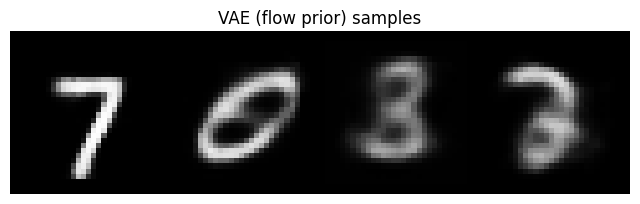

tensor([[[[4.7492e-05, 9.6832e-05, 5.6558e-05,  ..., 8.9340e-05,
           6.4810e-05, 6.6400e-05],
          [5.0925e-05, 6.8337e-05, 7.2513e-05,  ..., 4.2168e-05,
           7.2728e-05, 8.2268e-05],
          [6.7686e-05, 9.3695e-05, 6.3625e-05,  ..., 9.0293e-05,
           7.4073e-05, 8.0568e-05],
          ...,
          [6.3571e-05, 7.4888e-05, 6.0024e-05,  ..., 7.4872e-05,
           7.1405e-05, 6.7766e-05],
          [5.4873e-05, 8.7213e-05, 9.5747e-05,  ..., 7.4420e-05,
           4.4618e-05, 4.7207e-05],
          [5.1572e-05, 5.7739e-05, 6.5579e-05,  ..., 5.4435e-05,
           7.1950e-05, 4.0706e-05]]],


        [[[2.7459e-03, 2.5376e-03, 2.7401e-03,  ..., 2.8774e-03,
           2.6672e-03, 2.3102e-03],
          [2.8749e-03, 2.6157e-03, 2.5973e-03,  ..., 3.4414e-03,
           2.6904e-03, 2.6520e-03],
          [2.6701e-03, 2.5920e-03, 2.7892e-03,  ..., 2.4659e-03,
           2.4752e-03, 2.0773e-03],
          ...,
          [2.6304e-03, 3.3419e-03, 2.6141e-03,  ..., 2.28

In [5]:
vae_flow = VAEModel(
    device=device, beta=1.0, latent_dim=LATENT_DIM, hidden=VAE_HIDDEN,
    prior_type='flow', model_name='vae_flow',
)
vae_flow.train_model(train_loader, epochs=VAE_FLOW_EPOCHS, lr=VAE_FLOW_LR)
vae_flow.save(OUTDIR / 'vae_flow.pt')
show_samples(vae_flow, n=4, title='VAE (flow prior) samples',
             save_path=OUTDIR / 'samples_vae_flow.png')

β-VAE training: 100%|██████████| 1876/1876 [00:43<00:00, 42.84it/s, beta=1.000000, epoch=2/2, loss=739.6644, lr=5.00e-04]


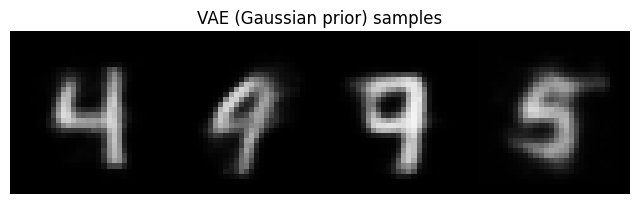

tensor([[[[0.0020, 0.0018, 0.0016,  ..., 0.0021, 0.0018, 0.0017],
          [0.0017, 0.0023, 0.0018,  ..., 0.0017, 0.0017, 0.0017],
          [0.0019, 0.0018, 0.0019,  ..., 0.0018, 0.0019, 0.0017],
          ...,
          [0.0018, 0.0020, 0.0018,  ..., 0.0021, 0.0018, 0.0017],
          [0.0026, 0.0018, 0.0022,  ..., 0.0021, 0.0028, 0.0018],
          [0.0017, 0.0016, 0.0018,  ..., 0.0021, 0.0019, 0.0017]]],


        [[[0.0009, 0.0008, 0.0011,  ..., 0.0010, 0.0010, 0.0012],
          [0.0012, 0.0009, 0.0010,  ..., 0.0011, 0.0010, 0.0009],
          [0.0009, 0.0012, 0.0010,  ..., 0.0009, 0.0010, 0.0011],
          ...,
          [0.0010, 0.0010, 0.0009,  ..., 0.0011, 0.0012, 0.0010],
          [0.0016, 0.0010, 0.0011,  ..., 0.0008, 0.0010, 0.0012],
          [0.0012, 0.0009, 0.0011,  ..., 0.0008, 0.0009, 0.0009]]],


        [[[0.0010, 0.0009, 0.0010,  ..., 0.0009, 0.0009, 0.0011],
          [0.0007, 0.0011, 0.0010,  ..., 0.0011, 0.0009, 0.0010],
          [0.0009, 0.0009, 0.0012,  ..

In [6]:
vae_gauss = VAEModel(
    device=device, beta=1.0, latent_dim=LATENT_DIM, hidden=VAE_HIDDEN,
    prior_type='gaussian', model_name='vae_gauss',
)
vae_gauss.train_model(train_loader, epochs=VAE_FLOW_EPOCHS, lr=VAE_FLOW_LR)
vae_gauss.save(OUTDIR / 'vae_gauss.pt')
show_samples(vae_gauss, n=4, title='VAE (Gaussian prior) samples',
             save_path=OUTDIR / 'samples_vae_gauss.png')

## 2.1b VAE (MoG Prior)

β-VAE training: 100%|██████████| 1876/1876 [00:49<00:00, 38.01it/s, beta=1.000000, epoch=2/2, loss=741.1176, lr=5.00e-04]


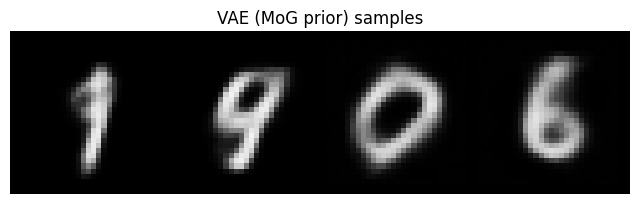

tensor([[[[1.7565e-04, 1.3777e-04, 1.2593e-04,  ..., 1.4248e-04,
           1.5888e-04, 1.0842e-04],
          [1.5798e-04, 1.1823e-04, 1.9566e-04,  ..., 1.1684e-04,
           1.1141e-04, 1.3212e-04],
          [1.5024e-04, 1.4344e-04, 1.5788e-04,  ..., 1.8386e-04,
           1.2139e-04, 1.1996e-04],
          ...,
          [1.5071e-04, 1.4409e-04, 9.3426e-05,  ..., 1.1910e-04,
           1.7741e-04, 1.2321e-04],
          [1.3715e-04, 1.3425e-04, 1.3705e-04,  ..., 1.5288e-04,
           1.2511e-04, 1.3236e-04],
          [1.3756e-04, 1.4241e-04, 1.8690e-04,  ..., 1.6498e-04,
           1.3499e-04, 1.3170e-04]]],


        [[[8.3795e-04, 1.1020e-03, 8.7468e-04,  ..., 9.5148e-04,
           1.0807e-03, 8.5488e-04],
          [1.0513e-03, 7.9125e-04, 7.6236e-04,  ..., 1.2426e-03,
           9.9945e-04, 9.1623e-04],
          [9.2905e-04, 1.0110e-03, 1.2454e-03,  ..., 1.0098e-03,
           9.1872e-04, 9.1940e-04],
          ...,
          [7.9508e-04, 1.0452e-03, 8.9583e-04,  ..., 9.06

In [7]:
vae_mog = VAEModel(
    device=device, beta=1.0, latent_dim=LATENT_DIM, hidden=VAE_HIDDEN,
    prior_type='mog', mog_components=10, model_name='vae_mog',
)
vae_mog.train_model(train_loader, epochs=VAE_FLOW_EPOCHS, lr=VAE_FLOW_LR)
vae_mog.save(OUTDIR / 'vae_mog.pt')
show_samples(vae_mog, n=4, title='VAE (MoG prior) samples',
             save_path=OUTDIR / 'samples_vae_mog.png')

## 2.1c VAE (Flow Prior, Bernoulli Decoder)

Uses a **Bernoulli decoder** (for binarised MNIST) instead of the default Gaussian decoder.
This matches the original Part A implementation.

β-VAE training: 100%|██████████| 1876/1876 [01:06<00:00, 28.42it/s, beta=1.000000, epoch=2/2, loss=113.3453, lr=5.00e-04]


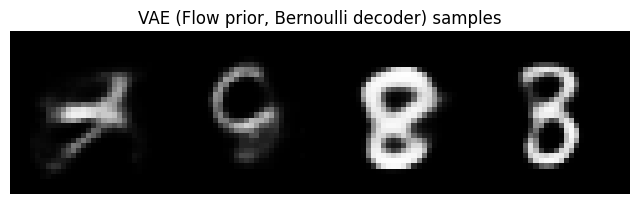

tensor([[[[2.8480e-04, 3.2965e-04, 3.4382e-04,  ..., 2.8372e-04,
           2.7754e-04, 3.6442e-04],
          [2.9902e-04, 2.8143e-04, 3.5516e-04,  ..., 3.8124e-04,
           2.9099e-04, 3.5269e-04],
          [2.5950e-04, 2.8790e-04, 2.7906e-04,  ..., 4.9884e-04,
           2.4738e-04, 2.8186e-04],
          ...,
          [3.4163e-04, 2.9207e-04, 3.1104e-04,  ..., 2.2403e-04,
           2.6894e-04, 3.2815e-04],
          [3.1594e-04, 2.7068e-04, 3.2847e-04,  ..., 4.4114e-04,
           2.8095e-04, 3.1624e-04],
          [2.6295e-04, 2.5386e-04, 2.2824e-04,  ..., 3.3690e-04,
           3.2556e-04, 2.6380e-04]]],


        [[[7.9028e-05, 9.0212e-05, 9.2305e-05,  ..., 1.1694e-04,
           1.0104e-04, 7.8155e-05],
          [8.9380e-05, 1.3065e-04, 1.1962e-04,  ..., 8.9445e-05,
           1.0738e-04, 1.1583e-04],
          [1.1222e-04, 9.8909e-05, 9.0257e-05,  ..., 2.7228e-05,
           1.2244e-04, 1.3208e-04],
          ...,
          [1.0314e-04, 9.6114e-05, 1.3748e-04,  ..., 1.48

In [8]:
vae_bernoulli = VAEModel(
    device=device, beta=1.0, latent_dim=LATENT_DIM, hidden=VAE_HIDDEN,
    prior_type='flow', decoder_type='bernoulli', model_name='vae_bernoulli',
)
vae_bernoulli.train_model(train_loader, epochs=VAE_FLOW_EPOCHS, lr=VAE_FLOW_LR)
vae_bernoulli.save(OUTDIR / 'vae_bernoulli.pt')
show_samples(vae_bernoulli, n=4, title='VAE (Flow prior, Bernoulli decoder) samples',
             save_path=OUTDIR / 'samples_vae_bernoulli.png')

## 2.2 Beta-VAE (Gaussian Prior)

β-VAE training: 100%|██████████| 1876/1876 [00:43<00:00, 42.76it/s, beta=1.000000, epoch=2/2, loss=739.8984, lr=5.00e-04]


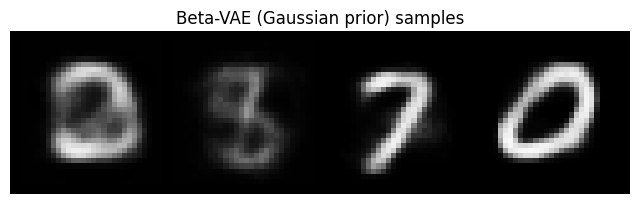

tensor([[[[0.0047, 0.0049, 0.0046,  ..., 0.0047, 0.0052, 0.0049],
          [0.0044, 0.0051, 0.0047,  ..., 0.0049, 0.0047, 0.0048],
          [0.0050, 0.0051, 0.0047,  ..., 0.0045, 0.0049, 0.0047],
          ...,
          [0.0049, 0.0044, 0.0047,  ..., 0.0049, 0.0046, 0.0045],
          [0.0048, 0.0048, 0.0049,  ..., 0.0050, 0.0047, 0.0051],
          [0.0047, 0.0050, 0.0050,  ..., 0.0047, 0.0043, 0.0045]]],


        [[[0.0072, 0.0058, 0.0059,  ..., 0.0062, 0.0059, 0.0068],
          [0.0070, 0.0070, 0.0070,  ..., 0.0066, 0.0069, 0.0069],
          [0.0065, 0.0066, 0.0065,  ..., 0.0068, 0.0068, 0.0058],
          ...,
          [0.0062, 0.0070, 0.0070,  ..., 0.0072, 0.0070, 0.0060],
          [0.0071, 0.0064, 0.0072,  ..., 0.0071, 0.0066, 0.0067],
          [0.0061, 0.0074, 0.0066,  ..., 0.0078, 0.0067, 0.0064]]],


        [[[0.0013, 0.0013, 0.0010,  ..., 0.0010, 0.0013, 0.0011],
          [0.0012, 0.0011, 0.0010,  ..., 0.0013, 0.0012, 0.0014],
          [0.0014, 0.0011, 0.0012,  ..

In [9]:
beta_vae = VAEModel(
    device=device, beta=1.0, latent_dim=LATENT_DIM, hidden=VAE_HIDDEN,
    prior_type='gaussian', model_name='beta_vae',
)
beta_vae.train_model(train_loader, epochs=BETA_VAE_EPOCHS, lr=BETA_VAE_LR)
beta_vae.save(OUTDIR / 'beta_vae.pt')
show_samples(beta_vae, n=4, title='Beta-VAE (Gaussian prior) samples',
             save_path=OUTDIR / 'samples_beta_vae.png')

## 2.3 DDPM U-Net (Pixel-space DDPM)

Training: 100%|██████████| 1876/1876 [01:15<00:00, 24.98it/s, epoch=2/2, loss=⠀     69.6744]


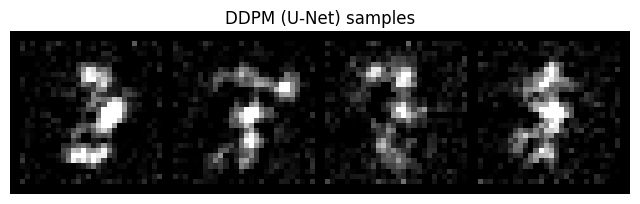

tensor([[[[0.1110, 0.0000, 0.1179,  ..., 0.0270, 0.1494, 0.0059],
          [0.1697, 0.0000, 0.0260,  ..., 0.0000, 0.0231, 0.0685],
          [0.0415, 0.0363, 0.0501,  ..., 0.0000, 0.0000, 0.0937],
          ...,
          [0.0000, 0.0362, 0.0000,  ..., 0.0000, 0.0343, 0.0000],
          [0.0000, 0.1102, 0.0000,  ..., 0.0221, 0.1034, 0.2358],
          [0.1803, 0.0000, 0.0000,  ..., 0.0000, 0.0675, 0.0000]]],


        [[[0.1005, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.1518, 0.0662, 0.0000,  ..., 0.0307, 0.0000, 0.0000],
          [0.0717, 0.0598, 0.0658,  ..., 0.0030, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0211, 0.0000,  ..., 0.0031, 0.0772, 0.1381],
          [0.1418, 0.0343, 0.1073,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0296,  ..., 0.0358, 0.0000, 0.1882]]],


        [[[0.1703, 0.0575, 0.0000,  ..., 0.0883, 0.0692, 0.0000],
          [0.0000, 0.0058, 0.0355,  ..., 0.0000, 0.0000, 0.0504],
          [0.1210, 0.0000, 0.0000,  ..

In [10]:
ddpm = DDPMUNetModel(device=device, T=DDPM_T)
ddpm.train_model(train_loader_ddpm, epochs=DDPM_UNET_EPOCHS, lr=DDPM_UNET_LR)
ddpm.save(OUTDIR / 'ddpm_unet.pt')
show_samples(ddpm, n=4, title='DDPM (U-Net) samples',
             save_path=OUTDIR / 'samples_ddpm_unet.png')

## 2.4 Latent DDPM (Flow-prior VAE + DDPM in z-space)

In [11]:
latent_ddpm = LatentDDPMModel(
    device=device,
    beta=LDDPM_BETA,
    latent_dim=LATENT_DIM,
    vae_hidden=VAE_HIDDEN,
    T=DDPM_T,
)

# Stage 1: Train the flow-prior VAE inside Latent DDPM
print('Stage 1: Training flow-prior VAE (Gaussian likelihood)...')
import inspect
sig = inspect.signature(latent_ddpm.train_vae)
if 'beta_warmup_epochs' in sig.parameters:
    latent_ddpm.train_vae(
        train_loader,
        epochs=LDDPM_VAE_EPOCHS,
        lr=LDDPM_VAE_LR,
        beta_warmup_epochs=int(LDDPM_VAE_WARMUP_EPOCHS),
    )
else:
    latent_ddpm.train_vae(
        train_loader,
        epochs=LDDPM_VAE_EPOCHS,
        lr=LDDPM_VAE_LR,
    )


--- Flow-Prior VAE Quality Check ---


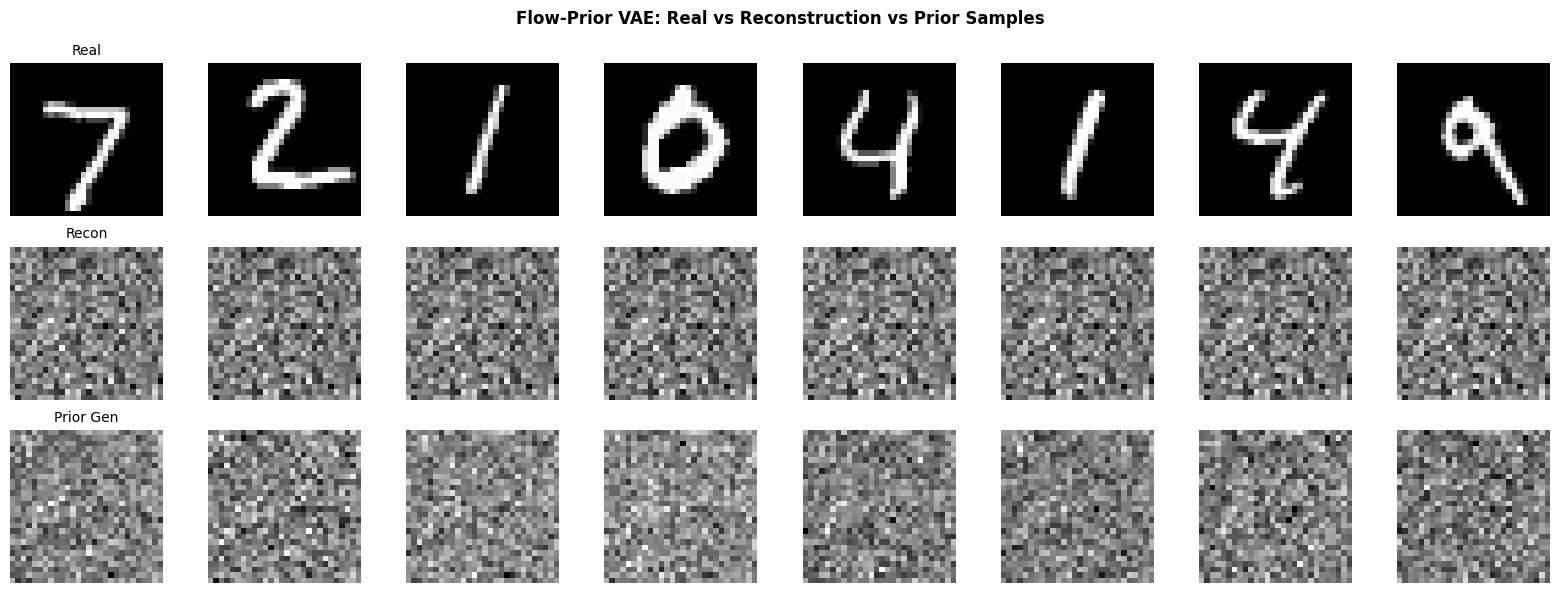

Quality check saved to beta_vae_quality_check.png


In [12]:
# Show comparison: Real vs reconstruction vs flow-prior sample
print('\n--- Flow-Prior VAE Quality Check ---')

real_batch = next(iter(test_loader))
if isinstance(real_batch, (list, tuple)):
    real_batch = real_batch[0]
real_flat = real_batch[:8].to(device)
if real_flat.dim() > 2:
    real_flat = real_flat.view(real_flat.size(0), -1)

with torch.no_grad():
    q = latent_ddpm.vae.encode(real_flat)
    recon = latent_ddpm.vae.decode_mean(q.mean)
    prior_gen = latent_ddpm.vae.sample(n_samples=8).to(device)

real_imgs = real_flat.view(-1, 1, 28, 28).clamp(0.0, 1.0).cpu()
recon_imgs = recon.view(-1, 1, 28, 28).clamp(0.0, 1.0).cpu()
gen_imgs = prior_gen.view(-1, 1, 28, 28).clamp(0.0, 1.0).cpu()

fig, axes = plt.subplots(3, 8, figsize=(16, 6))
for i in range(8):
    axes[0, i].imshow(real_imgs[i, 0].numpy(), cmap='gray')
    axes[0, i].set_title('Real' if i == 0 else '', fontsize=10)
    axes[0, i].axis('off')
    axes[1, i].imshow(recon_imgs[i, 0].numpy(), cmap='gray')
    axes[1, i].set_title('Recon' if i == 0 else '', fontsize=10)
    axes[1, i].axis('off')
    axes[2, i].imshow(gen_imgs[i, 0].numpy(), cmap='gray')
    axes[2, i].set_title('Prior Gen' if i == 0 else '', fontsize=10)
    axes[2, i].axis('off')

fig.suptitle('Flow-Prior VAE: Real vs Reconstruction vs Prior Samples', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTDIR / 'beta_vae_quality_check.png', dpi=120, bbox_inches='tight')
plt.show()
print('Quality check saved to beta_vae_quality_check.png')

In [13]:
# Stage 2: Train the latent DDPM
print('\nStage 2: Training DDPM in latent space...')
latent_ddpm.train_ddpm(train_loader, epochs=LDDPM_DDPM_EPOCHS, lr=LDDPM_DDPM_LR)

latent_ddpm.save(OUTDIR / 'latent_ddpm.pt')
print('Saved latent DDPM model.')


Stage 2: Training DDPM in latent space...


Training: 100%|██████████| 1876/1876 [00:12<00:00, 151.17it/s, epoch=2/2, loss=⠀      0.1962]


Saved latent DDPM model.



--- Latent DDPM Diagnostic ---
Comparing: VAE Prior Sampling vs Trained DDPM in Latent Space



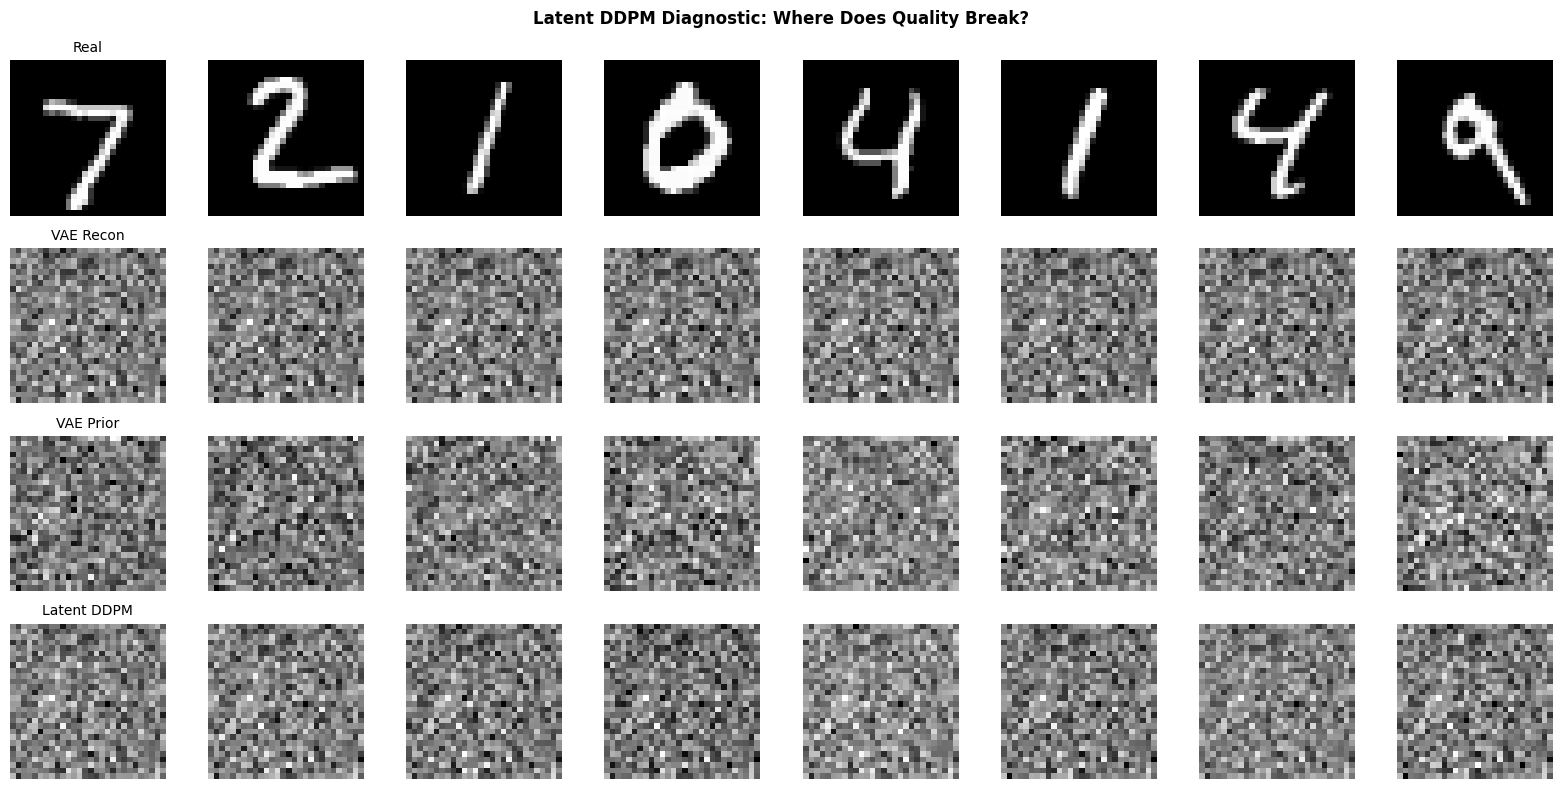

DIAGNOSIS:
  Row 1 (Real): Ground truth
  Row 2 (VAE Recon): Should be sharp -- checks if VAE encoder works
  Row 3 (VAE Prior): z ~ flow prior -- checks if VAE prior is aligned
  Row 4 (Latent DDPM): z ~ DDPM -- checks if DDPM improved the prior

If Row 3 is blurry: beta is too low -- increase beta
If Row 3 is OK but Row 4 is worse: DDPM training failed -- more epochs needed
Diagnostic saved to latent_ddpm_diagnostic.png


In [14]:
# DIAGNOSTIC: Compare VAE Prior vs Latent DDPM
print('\n--- Latent DDPM Diagnostic ---')
print('Comparing: VAE Prior Sampling vs Trained DDPM in Latent Space\n')

real_batch = next(iter(test_loader))
if isinstance(real_batch, (list, tuple)):
    real_batch = real_batch[0]
real_flat = real_batch[:8].to(device)
if real_flat.dim() > 2:
    real_flat = real_flat.view(real_flat.size(0), -1)

with torch.no_grad():
    q = latent_ddpm.vae.encode(real_flat)
    vae_recon = latent_ddpm.vae.decode_mean(q.mean)
    vae_prior_gen = latent_ddpm.vae.sample(n_samples=8).to(device)
    ddpm_samples = latent_ddpm.sample(n_samples=8).to(device)
    if ddpm_samples.dim() == 4:
        ddpm_samples = ddpm_samples.view(ddpm_samples.size(0), -1)

real_imgs = real_flat.view(-1, 1, 28, 28).clamp(0.0, 1.0).cpu()
recon_imgs = vae_recon.view(-1, 1, 28, 28).clamp(0.0, 1.0).cpu()
vae_prior_imgs = vae_prior_gen.view(-1, 1, 28, 28).clamp(0.0, 1.0).cpu()
ddpm_imgs = ddpm_samples.view(-1, 1, 28, 28).clamp(0.0, 1.0).cpu()

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for i in range(8):
    axes[0, i].imshow(real_imgs[i, 0].numpy(), cmap='gray')
    axes[0, i].set_title('Real' if i == 0 else '', fontsize=10)
    axes[0, i].axis('off')
    axes[1, i].imshow(recon_imgs[i, 0].numpy(), cmap='gray')
    axes[1, i].set_title('VAE Recon' if i == 0 else '', fontsize=10)
    axes[1, i].axis('off')
    axes[2, i].imshow(vae_prior_imgs[i, 0].numpy(), cmap='gray')
    axes[2, i].set_title('VAE Prior' if i == 0 else '', fontsize=10)
    axes[2, i].axis('off')
    axes[3, i].imshow(ddpm_imgs[i, 0].numpy(), cmap='gray')
    axes[3, i].set_title('Latent DDPM' if i == 0 else '', fontsize=10)
    axes[3, i].axis('off')

fig.suptitle('Latent DDPM Diagnostic: Where Does Quality Break?', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTDIR / 'latent_ddpm_diagnostic.png', dpi=120, bbox_inches='tight')
plt.show()

print('DIAGNOSIS:')
print('  Row 1 (Real): Ground truth')
print('  Row 2 (VAE Recon): Should be sharp -- checks if VAE encoder works')
print('  Row 3 (VAE Prior): z ~ flow prior -- checks if VAE prior is aligned')
print('  Row 4 (Latent DDPM): z ~ DDPM -- checks if DDPM improved the prior')
print()
print('If Row 3 is blurry: beta is too low -- increase beta')
print('If Row 3 is OK but Row 4 is worse: DDPM training failed -- more epochs needed')
print('Diagnostic saved to latent_ddpm_diagnostic.png')

---
# 3. Evaluation

## 3.1 Visual Comparison: Real MNIST vs Generated Samples

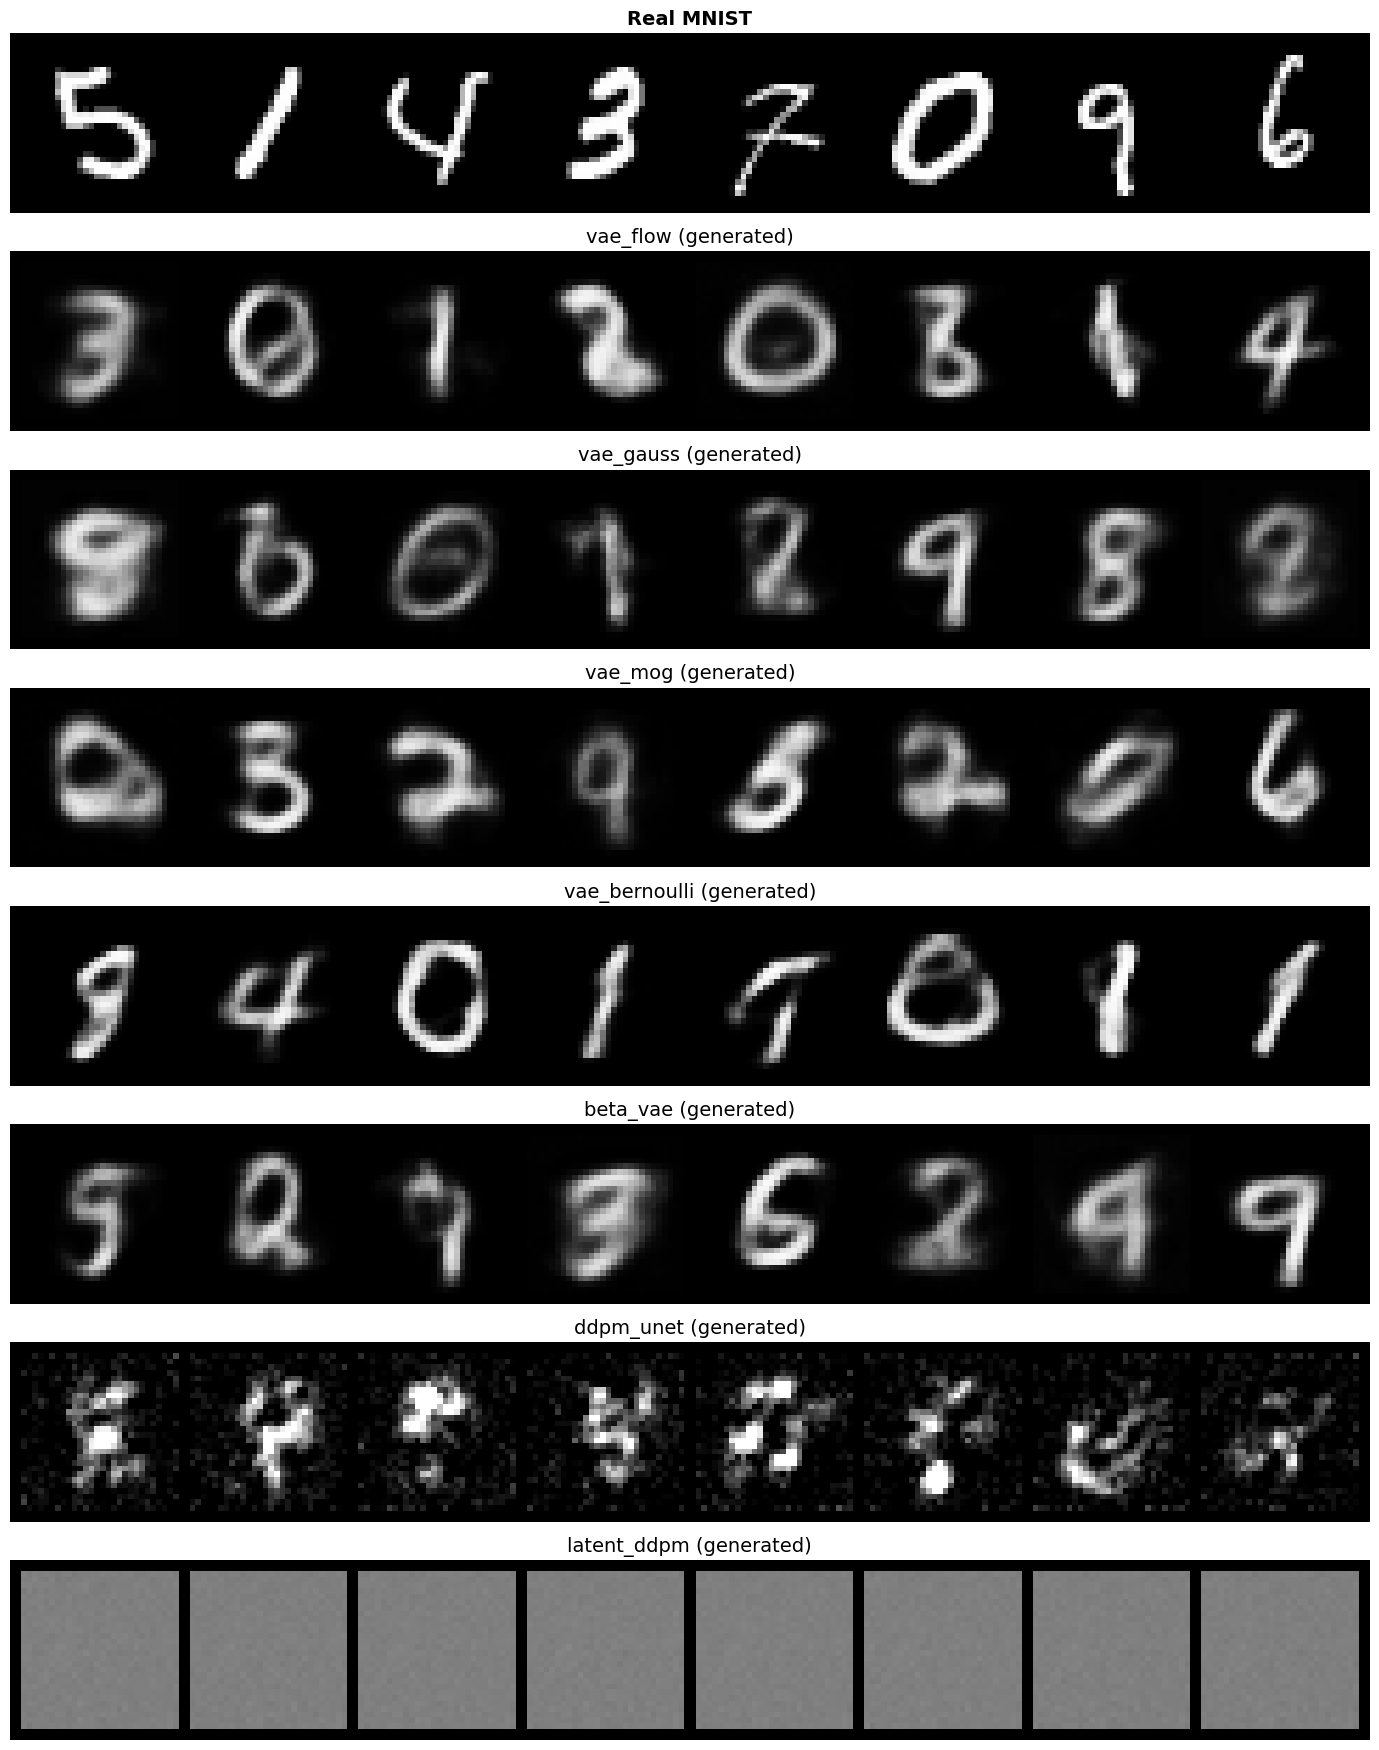

In [15]:
def show_comparison(real_loader, models, n_samples=8, save_path=None):
    """Top row = real MNIST, then one row per model with generated samples."""
    real_batch = next(iter(real_loader))
    if isinstance(real_batch, (list, tuple)):
        real_batch = real_batch[0]
    real_imgs = real_batch[:n_samples].cpu()
    if real_imgs.dim() == 2:
        real_imgs = real_imgs.view(-1, 1, 28, 28)
    real_imgs = real_imgs.clamp(0.0, 1.0)

    n_rows = 1 + len(models)
    fig, axes = plt.subplots(n_rows, 1, figsize=(n_samples * 2, 2.2 * n_rows))
    if n_rows == 1:
        axes = [axes]

    grid_real = make_grid(real_imgs, nrow=n_samples, padding=2, normalize=False)
    axes[0].imshow(grid_real.permute(1, 2, 0).squeeze(-1).numpy(), cmap='gray')
    axes[0].set_title('Real MNIST', fontsize=14, fontweight='bold')
    axes[0].axis('off')

    for i, m in enumerate(models):
        with torch.no_grad():
            gen = m.sample(n_samples).cpu().clamp(0.0, 1.0)
        if gen.dim() == 2:
            gen = gen.view(-1, 1, 28, 28)
        grid_gen = make_grid(gen, nrow=n_samples, padding=2, normalize=False)
        axes[i + 1].imshow(grid_gen.permute(1, 2, 0).squeeze(-1).numpy(), cmap='gray')
        axes[i + 1].set_title(f'{m.name} (generated)', fontsize=14)
        axes[i + 1].axis('off')

    plt.tight_layout()
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()

# All models (including new VAE variants)
models_to_eval = [vae_flow, vae_gauss, vae_mog, vae_bernoulli, beta_vae, ddpm, latent_ddpm]

show_comparison(
    train_loader, models_to_eval, n_samples=8,
    save_path=OUTDIR / 'comparison_real_vs_generated.png',
)

## 3.2 FID Scores

In [16]:
fid_results = {}
for m in models_to_eval:
    fid = evaluate_fid(m, n_gen=N_FID, device=device)
    fid_results[m.name] = fid
    print(f'{m.name:20s}  FID = {fid:.2f}')

vae_flow              FID = 134.59-0.00j
vae_gauss             FID = 148.36-0.00j
vae_mog               FID = 134.95-0.00j
vae_bernoulli         FID = 68.96-0.00j
beta_vae              FID = 142.38-0.00j
ddpm_unet             FID = 210.14-0.00j
latent_ddpm           FID = 506.41-0.00j


## 3.3 FID vs β (Latent DDPM)

Sweep over different β values for the β-VAE inside the Latent DDPM.

In [ ]:
# β values to sweep (adjust as needed)
betas_to_test = [1e-6, 1e-4, 1e-2, 1e-1, 1.0]

beta_fid_results = fid_vs_beta(
    betas=betas_to_test,
    train_loader=train_loader,
    device=device,
    latent_dim=LATENT_DIM,
    vae_epochs=LDDPM_VAE_EPOCHS,
    ddpm_epochs=LDDPM_DDPM_EPOCHS,
    n_fid=N_FID,
    save_path=OUTDIR / 'fid_vs_beta.png',
)

for b, f in beta_fid_results.items():
    print(f'  β = {b:.1e}  →  FID = {f:.2f}')


--- β = 1e-06 ---


β-VAE training:   0%|          | 4/1876 [00:00<01:02, 29.72it/s, beta=0.000000, epoch=1/2, loss=767.6559, lr=1.00e-03]

ValueError: Expected value argument (Tensor of shape (64, 16)) to be within the support (Real()) of the distribution Normal(loc: torch.Size([16]), scale: torch.Size([16])), but found invalid values:
tensor([[-1.5883, -1.5616,  0.5909,  ...,  0.5804,  0.6672, -0.3059],
        [-0.4139,  0.4037, -9.9933,  ..., -1.7372,  0.3213,  0.1398],
        [-0.6329, -2.7248, -0.3732,  ..., -1.7827, -1.5621,  0.3135],
        ...,
        [ 0.0654,  1.5178,  0.1286,  ..., -1.4525, -2.5093,  1.6367],
        [-0.0142,  2.3217, -1.3261,  ..., -0.2252,  2.3567, -0.1281],
        [-3.3480,  1.3686, -0.8280,  ...,  0.6908,  7.6967, -0.0714]],
       device='cuda:0', grad_fn=<AddBackward0>)

β-VAE training:   0%|          | 5/1876 [00:10<01:02, 29.72it/s, beta=0.000000, epoch=1/2, loss=767.6559, lr=1.00e-03]

## 3.4 Sampling Speed

In [ ]:
speed_results = {}
for m in models_to_eval:
    sr = measure_sampling_speed(m, n_samples=100)
    speed_results[m.name] = sr
    print(f"{m.name:20s}  {sr['samples_per_sec']:.1f} samples/s  "
          f"({sr['total_time_s']:.2f}s for {sr['n_samples']} samples)")

## 3.5 Latent Space Analysis

Compare three distributions in the first two latent dimensions:
- **VAE prior** — $\mathcal{N}(0, I)$
- **Aggregate posterior** — $\frac{1}{N} \sum q(z \mid x_i)$
- **Learned DDPM prior** — samples from the latent-space DDPM

In [ ]:
plot_latent_distributions(
    latent_ddpm,
    train_loader,
    dims=(0, 1),
    n_samples=5000,
    save_path=OUTDIR / 'latent_distributions.png',
)